In [2]:
import duckdb
import matplotlib.pyplot as plt

In [3]:
project_root_path = "../../"
customers_path = project_root_path + "data/customers.parquet"

In [4]:
# Load customers table
customers = duckdb.read_parquet(customers_path)

# Sales
purchase = duckdb.sql("SELECT * FROM customers WHERE event_type = 'purchase'")

In [5]:
# Describe price column
duckdb.sql("SELECT price FROM purchase").df().describe()

,price
count,1.286088e+06
mean,4.933148e+00
std,8.927053e+00
min,-7.937000e+01
25%,1.590000e+00
50%,3.000000e+00
75%,5.400000e+00
max,3.277800e+02


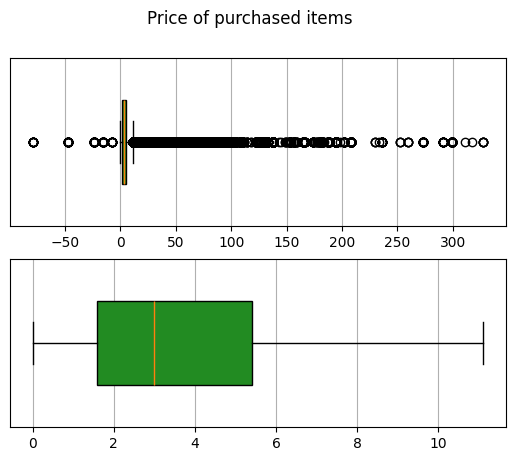

In [36]:
# Price of items purchased
price = duckdb.sql("SELECT price FROM purchase").fetchnumpy()['price']

bplot = []

fig, axs = plt.subplots(2, 1)
fig.suptitle("Price of purchased items")

bplot.append(axs[0].boxplot(price, orientation='horizontal', widths=0.5,
                            patch_artist=True))
bplot.append(axs[1].boxplot(price, orientation='horizontal', widths=0.5,
                            showfliers=False, patch_artist=True))

for ax, b in zip(axs, bplot):
    ax.set_yticks([])
    ax.grid()
    b['boxes'][0].set_facecolor('forestgreen')

plt.show()

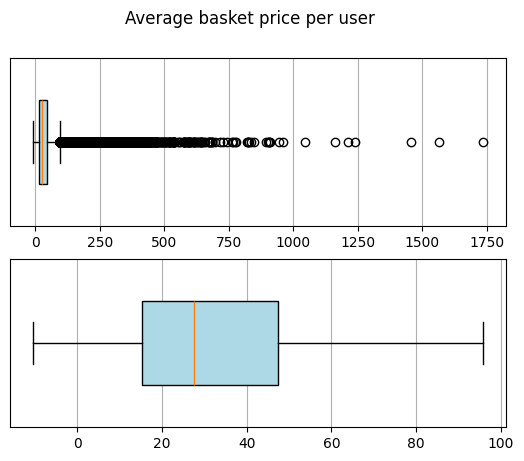

In [29]:
# Average basket price per user
avg_price = duckdb.sql(
"""
SELECT user_id, AVG(basket_price) as avg_price FROM (
    SELECT user_id, user_session, SUM(price) AS basket_price
    FROM purchase
    GROUP BY user_session, user_id
)
GROUP BY user_id
""").fetchnumpy()['avg_price']

bplot = []

fig, axs = plt.subplots(2, 1)
fig.suptitle("Average basket price per user")

bplot.append(axs[0].boxplot(avg_price, orientation='horizontal', widths=0.5,
                            patch_artist=True))
bplot.append(axs[1].boxplot(avg_price, orientation='horizontal', widths=0.5,
                            showfliers=False, patch_artist=True))

for ax, b in zip(axs, bplot):
    ax.set_yticks([])
    ax.grid()
    b['boxes'][0].set_facecolor('lightblue')

plt.show()